In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("weather_Rourkela_2021_2022-selected-columns.csv")


In [3]:
print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())


First 5 rows:
         time  tavg  tmin  tmax  prcp  snow   wdir  wspd  wpgt    pres
0  2021-07-06  29.3  26.2  32.6   NaN   NaN  197.0   6.8   NaN  1002.5
1  2021-07-07  29.7  27.3  33.4  11.1   NaN  199.0   6.9   NaN  1002.2
2  2021-07-08  27.4  25.8  29.7  66.9   NaN  186.0   6.3   NaN  1001.8
3  2021-07-09  28.5  26.1  32.1  11.4   NaN  173.0   3.9   NaN  1001.0
4  2021-07-10  29.0  26.2  32.6   2.7   NaN  121.0   4.6   NaN  1000.9

Dataset shape:
(426, 10)

Column names:
Index(['time', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt',
       'pres'],
      dtype='object')

Missing values:
time      0
tavg      2
tmin      2
tmax      2
prcp      3
snow    426
wdir      2
wspd      2
wpgt    426
pres      2
dtype: int64


In [4]:
X = df[['tmin', 'tmax', 'prcp', 'wspd', 'pres']]


y = df['tavg']


In [5]:
data = pd.concat([X, y], axis=1)

data = data.dropna()

X = data[['tmin', 'tmax', 'prcp', 'wspd', 'pres']]
y = data['tavg']


print("\nData after removing missing values:")
print(data.shape)



Data after removing missing values:
(423, 6)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (338, 5)
Testing data: (85, 5)


In [7]:
model = LinearRegression()

In [8]:
model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test)


In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


========== MODEL PERFORMANCE ==========
Mean Absolute Error (MAE): 0.2941789177580979
Mean Squared Error (MSE): 0.16501399254229998
Root Mean Squared Error (RMSE): 0.4062191434956014
R² Score: 0.9911312075270007


In [11]:
print("\n========== MODEL COEFFICIENTS ==========")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

print("Intercept:", model.intercept_)



========== MODEL COEFFICIENTS ==========
tmin : 0.4818110837897022
tmax : 0.5159494293565526
prcp : 0.0009971008405939563
wspd : -0.009976679200908375
pres : -0.00046202076391094193
Intercept: -0.1268818000941998


In [12]:
results = pd.DataFrame({
    'Actual Temperature': y_test.values,
    'Predicted Temperature': y_pred
})

print("\n========== ACTUAL VS PREDICTED ==========")
print(results.head(20))




========== ACTUAL VS PREDICTED ==========
    Actual Temperature  Predicted Temperature
0                 19.6              19.974554
1                 33.9              33.487065
2                 19.3              19.032328
3                 28.7              28.529334
4                 29.1              28.864460
5                 28.5              28.253621
6                 23.7              23.961668
7                 25.4              25.449878
8                 28.2              28.419213
9                 27.9              27.766371
10                27.4              27.224541
11                28.8              28.487147
12                31.8              32.243274
13                28.1              28.276616
14                29.1              28.433342
15                28.3              28.290971
16                29.6              29.115750
17                26.6              25.965485
18                16.6              16.282628
19                21.9              2

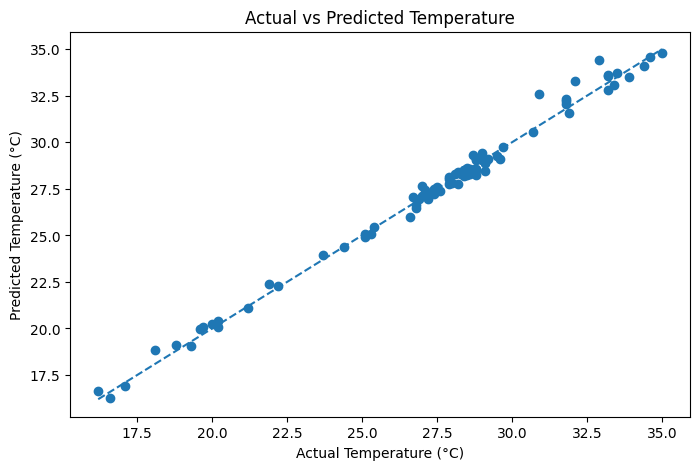

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Temperature")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()


In [14]:
new_data = pd.DataFrame({
    'tmin': [25],
    'tmax': [33],
    'prcp': [5],
    'wspd': [6],
    'pres': [1002]
})

predicted_temperature = model.predict(new_data)

print("\n========================================")
print("Predicted Average Temperature:")
print(predicted_temperature[0], "°C")
print("========================================")


Predicted Average Temperature:
28.42690708697335 °C
